# 03 · Inverse Policy Design via Constrained Optimization

The web app answers the **forward** question — *given this modal split, what happens?* This notebook answers the **inverse** question:

> *What modal split **minimises CO₂** (or full social cost) subject to a commute-time ceiling, an equity floor, and political-feasibility bounds?*

We solve it two ways and report both:

1. **Convex relaxation (CVXPY).** Emissions are linear in the modal-share vector $m$. Freezing car/bus speeds at a fixed congestion operating point makes the commute-time and equity constraints linear too, so the feasible set is a polytope and the solution is the **global optimum of the relaxation**.
2. **Nonlinear refinement (SLSQP).** Re-introduces the BPR congestion feedback (less driving → less congestion → faster cars), warm-started from the convex solution.

The convex solve is fast and globally optimal but conservative on travel time; the nonlinear solve is exact for this model but only locally optimal. Together they bracket the true answer.

In [1]:
import sys, json; sys.path.append('..')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from optimization import PolicyTargets, optimize_convex, optimize_nonlinear, POLICY_LIBRARY
from engine import BPRParams, calculate_metrics, BASELINE_MIX, MODES

# Use the Bayesian-calibrated coefficients from notebook 01.
cal = json.load(open('../../src/models/calibrated.json'))
bpr = BPRParams(**cal['bpr'])
print('Calibrated BPR:', cal['bpr'])

Calibrated BPR: {'alpha': 0.2618, 'beta': 2.3912, 'gamma': 6.1597, 'v_free': 31.8229}


## One worked policy: the Net-Zero Push

Targets: minimise CO₂, average commute ≤ 26 min, equity sub-score ≥ 60, car share ≤ 20%, plus a surface-transit coverage floor (bus ≥ 8%) and a walking cap (≤ 20%, since the mean trip is 4.8 km).

In [2]:
tgt = PolicyTargets(name='net_zero_push', objective='co2',
                    max_commute_min=26.0, min_equity=60.0, car_max=0.20)

convex = optimize_convex(tgt, bpr)
nonlin = optimize_nonlinear(tgt, x0={k: v/100 for k, v in convex.items()}, bpr=bpr)

comp = pd.DataFrame({
    'baseline':  BASELINE_MIX,
    'convex LP': {k: round(v, 1) for k, v in convex.items()},
    'SLSQP':     {k: round(v, 1) for k, v in nonlin.items()},
}).T[MODES]
comp

,car,bus,subway,cycling,pedestrian,other
baseline,34.0,18.0,31.0,6.0,9.0,2.0
convex LP,5.0,8.0,28.4,42.0,16.6,0.0
SLSQP,5.0,8.0,28.4,42.0,16.6,0.0


In [3]:
base_m = calculate_metrics(BASELINE_MIX, bpr)
opt_m  = calculate_metrics(nonlin, bpr)
print(f"CO2:     {base_m['co2_tonnes']:7.1f} t  ->  {opt_m['co2_tonnes']:7.1f} t   "
      f"({(opt_m['co2_tonnes']/base_m['co2_tonnes']-1)*100:+.0f}%)")
print(f"Commute: {base_m['avg_commute_min']:7.1f} m  ->  {opt_m['avg_commute_min']:7.1f} m")
print(f"Equity:  {base_m['equity_index']:7.1f}   ->  {opt_m['equity_index']:7.1f}")
print(f"Grade:   {base_m['overall_score']:7.1f}   ->  {opt_m['overall_score']:7.1f}")

CO2:       199.3 t  ->     56.4 t   (-72%)
Commute:    33.7 m  ->     26.0 m
Equity:     52.0   ->     76.0
Grade:      15.2   ->     40.8


## The policy library

Three reference briefs — each a different objective/constraint set. Their solutions are exported to `src/models/calibrated.json` and ship as the **Optimizer ·** presets in the web app.

In [4]:
rows = []
for t in POLICY_LIBRARY:
    cx = optimize_convex(t, bpr)
    nl = optimize_nonlinear(t, x0={k: v/100 for k, v in cx.items()}, bpr=bpr)
    m = calculate_metrics(nl, bpr)
    rows.append({'policy': t.name, 'objective': t.objective,
                 **{k: round(nl[k], 1) for k in MODES},
                 'CO2 t': round(m['co2_tonnes'], 1),
                 'commute': round(m['avg_commute_min'], 1)})
pd.DataFrame(rows).set_index('policy')

,objective,car,bus,subway,cycling,pedestrian,other,CO2 t,commute
policy,,,,,,,,,
net_zero_push,co2,5.0,8.0,28.4,42.0,16.6,0.0,56.4,26.0
commuter_friendly,co2,5.0,8.0,40.6,42.0,4.4,0.0,61.4,20.0
lowest_cost,cost,5.0,8.0,32.5,42.0,12.5,0.0,58.0,24.0


## Pareto frontier: CO₂ vs. commute time

There is no single "best" modal split — only trade-offs. Sweeping the commute-time ceiling and re-solving traces the **Pareto frontier**: the set of modal splits where you cannot cut emissions further without lengthening commutes.

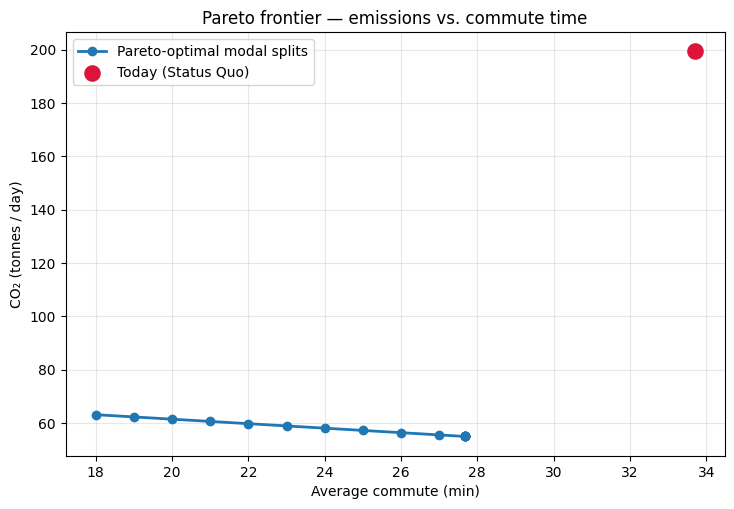

In [5]:
frontier = []
for tmax in np.arange(18, 34, 1.0):
    t = PolicyTargets(objective='co2', max_commute_min=float(tmax),
                      min_equity=55.0, car_max=0.34)
    try:
        cx = optimize_convex(t, bpr)
        nl = optimize_nonlinear(t, x0={k: v/100 for k, v in cx.items()}, bpr=bpr)
        m = calculate_metrics(nl, bpr)
        frontier.append((m['avg_commute_min'], m['co2_tonnes']))
    except RuntimeError:
        pass  # infeasible ceiling

fr = np.array(frontier)
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.plot(fr[:, 0], fr[:, 1], 'o-', lw=2, label='Pareto-optimal modal splits')
ax.scatter([base_m['avg_commute_min']], [base_m['co2_tonnes']], c='crimson',
           s=120, zorder=5, label='Today (Status Quo)')
ax.set_xlabel('Average commute (min)'); ax.set_ylabel('CO₂ (tonnes / day)')
ax.set_title('Pareto frontier — emissions vs. commute time')
ax.legend(); ax.grid(alpha=0.3); plt.show()

## Finding

The status-quo point sits **far above and to the right of the frontier** — today's modal split is Pareto-dominated, meaning Toronto could cut downtown transport CO₂ *and* shorten commutes simultaneously. The frontier itself is steep at the left edge: squeezing the last few minutes off the commute ceiling costs a disproportionate amount of emissions, because it forces riders out of slow active modes and onto the subway.

The three library solutions are the artefact this notebook ships: `export_results.py` writes them to `calibrated.json`, and they appear in the app as data-derived presets rather than hand-tuned guesses.